Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [2]:
# Parameters
NUM_BREEDS = 60
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

TRAIN_DIR = "C:/Users/GOVIND MOHARIL/OneDrive/Desktop/DOG BREED CLASSIFICATION RESNET,VGG,GOOGLENET/Dog-Breed-Identifier-main/train"
LABELS_CSV = r"C:\Users\GOVIND MOHARIL\OneDrive\Desktop\DOG BREED CLASSIFICATION RESNET,VGG,GOOGLENET\Dog-Breed-Identifier-main\labels.csv"

In [3]:
# Load data
df = pd.read_csv(LABELS_CSV)

# Select top breeds
top_breeds = df['breed'].value_counts().index[:NUM_BREEDS]
df = df[df['breed'].isin(top_breeds)]

print("Total images:", len(df))

Total images: 5720


In [4]:
# Label encodeing
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['breed'])

In [5]:
# Load Images
X = []
y = []

for i in range(len(df)):
    img_id = df.iloc[i]['id']
    label = df.iloc[i]['label']

    path = os.path.join(TRAIN_DIR, img_id + ".jpg")

    img = Image.open(path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img)

    X.append(img)
    y.append(label)

X = np.array(X, dtype='float32')
y = np.array(y)

# Preprocess
X = preprocess_input(X)

# One-hot
y = to_categorical(y, NUM_BREEDS)

In [6]:
# Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Build Model
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = BatchNormalization()(x)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)

output = Dense(NUM_BREEDS, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [9]:
# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train Model
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.2651 - loss: 3.4276 - val_accuracy: 0.6652 - val_loss: 2.2256
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 133s 934ms/step - accuracy: 0.6602 - loss: 1.6784 - val_accuracy: 0.7911 - val_loss: 0.9515
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 142s 995ms/step - accuracy: 0.7625 - loss: 0.9333 - val_accuracy: 0.8226 - val_loss: 0.6800
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 140s 977ms/step - accuracy: 0.8105 - loss: 0.6935 - val_accuracy: 0.8374 - val_loss: 0.5911
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 127s 886ms/step - accuracy: 0.8488 - loss: 0.5436 - val_accuracy: 0.8400 - val_loss: 0.5612
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 133s 928ms/step - accuracy: 0.8719 - loss: 0.4509 - val_accuracy: 0.8427 - val_loss: 0.5408
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.8842 - loss: 0.3959 - val_accuracy: 0.8497 - val_loss: 0.5279
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9012 - loss: 0.

In [11]:
# Evaluation
loss, acc = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", acc * 100)

36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 745ms/step - accuracy: 0.8549 - loss: 0.5326
Final Test Accuracy: 85.48951148986816


In [22]:
# Classification Report
# print(classification_report(y_true, y_pred_classes))

In [29]:
# # Confusion Matrix
# y_pred = model.predict(x_test)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = np.argmax(y_test, axis=1)

# cm = confusion_matrix(y_true, y_pred_classes)

# import seaborn as sns
# plt.figure(figsize=(10,8))
# sns.heatmap(cm, cmap="Blues")
# plt.title("Confusion Matrix")
# plt.show()

In [30]:
# # Sample Predictions
# for i in range(5):
#     plt.imshow((x_test[i] + 1) * 127.5)  # reverse preprocess
#     pred = y_pred_classes[i]
#     actual = y_true[i]

#     plt.title(f"Pred: {encoder.inverse_transform([pred])[0]} | Actual: {encoder.inverse_transform([actual])[0]}")
#     plt.axis('on')
#     plt.show()

In [12]:
# Save Model
model.save("dog_breed_model.keras")

In [13]:
# Prediction function
def predict_image(img_path):
    img = Image.open(img_path).convert('RGB')
    img = img.resize((IMG_SIZE, IMG_SIZE))
    img = np.array(img)

    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)
    class_idx = np.argmax(preds)

    breed = encoder.inverse_transform([class_idx])[0]
    confidence = preds[0][class_idx]

    return breed, confidence

In [14]:
# Test with a new image
# img_path = r"C:\Users\GOVIND MOHARIL\OneDrive\Desktop\DOG BREED CLASSIFICATION RESNET,VGG,GOOGLENET\images (1).jpg"
img_path = r"C:\Users\GOVIND MOHARIL\Downloads\img002.jpg"
img = Image.open(img_path)
img.show()
img = img.resize((IMG_SIZE, IMG_SIZE))
img_array = np.expand_dims(np.array(img).astype(np.float32), axis=0)
img_array = preprocess_input(img_array)

# Predict the breed probabilities and measure confidence
predictions = model.predict(img_array)
confidence = float(np.max(predictions))
confidence_pct = confidence * 100

# Show the breed only if prediction confidence crosses the threshold
confidence_threshold = 0.60
if confidence < confidence_threshold:
    print("Image is not a dog breed from this model or confidence is too low.")
    print(f"Top predicted confidence: {confidence_pct:.2f}%")
else:
    pred_label = np.argmax(predictions, axis=1)
    pred_breed = encoder.inverse_transform(pred_label)
    print(f"Predicted Breed for this Dog is: {pred_breed[0]} (confidence {confidence_pct:.2f}%)")




1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Breed for this Dog is: miniature_pinscher (confidence 92.20%)


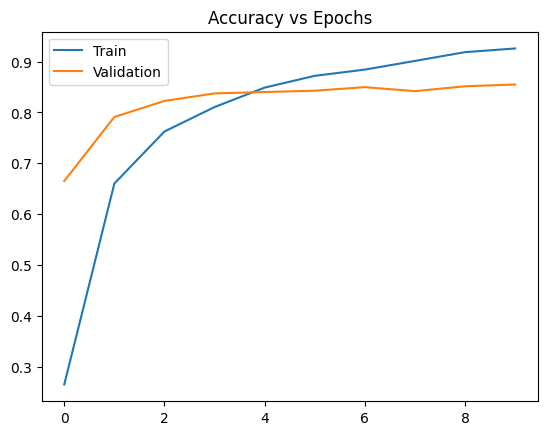

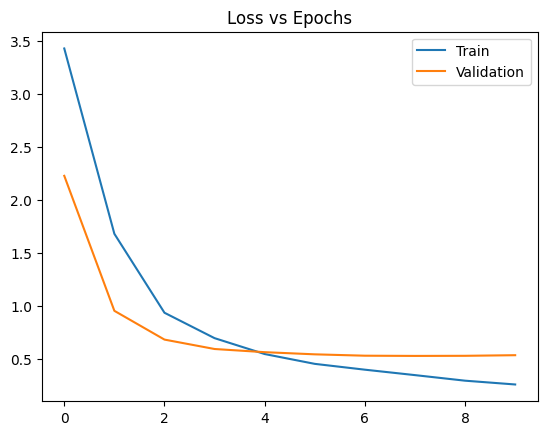

In [16]:
# Plot Graphs
# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy vs Epochs")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss vs Epochs")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
# from sklearn.metrics import classification_report, f1_score
# import pandas as pd
# import numpy as np

# # Convert predictions
# y_pred = model.predict(x_test)
# y_pred_classes = np.argmax(y_pred, axis=1)
# y_true = np.argmax(y_test, axis=1)

# # =========================
# # 1. OVERALL F1 SCORE
# # =========================
# f1_macro = f1_score(y_true, y_pred_classes, average='macro')
# f1_weighted = f1_score(y_true, y_pred_classes, average='weighted')

# print("F1 Score (Macro):", round(f1_macro, 4))
# print("F1 Score (Weighted):", round(f1_weighted, 4))

# # =========================
# # 2. PER-CLASS REPORT
# # =========================
# class_names = encoder.classes_

# report = classification_report(
#     y_true,
#     y_pred_classes,
#     target_names=class_names,
#     output_dict=True
# )

# # Convert to DataFrame for better display
# report_df = pd.DataFrame(report).transpose()

# print("\nPer-Class Classification Report:")
# print(report_df)

# # Optional: Save report
# report_df.to_csv("classification_report.csv")

36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 660ms/step
F1 Score (Macro): 0.8507
F1 Score (Weighted): 0.8507

Per-Class Classification Report:
                     precision    recall  f1-score     support
afghan_hound          0.956522  0.956522  0.956522    23.00000
african_hunting_dog   0.944444  1.000000  0.971429    17.00000
airedale              0.857143  0.857143  0.857143    21.00000
australian_terrier    0.640000  0.761905  0.695652    21.00000
basenji               0.826087  0.863636  0.844444    22.00000
...                        ...       ...       ...         ...
weimaraner            0.941176  0.941176  0.941176    17.00000
whippet               0.545455  0.631579  0.585366    19.00000
accuracy              0.849650  0.849650  0.849650     0.84965
macro avg             0.859270  0.847877  0.850662  1144.00000
weighted avg          0.857318  0.849650  0.850687  1144.00000

[63 rows x 4 columns]
